Columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

First 5 rows:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31



Sector Allocation:


,Total Weight
sector,
Banking,652.26
IT,455.47
Pharma,407.45
Automobile,323.65
Utilities,265.54
FMCG,229.11
Infrastructure,192.16
Diversified,169.23
Telecom,145.62


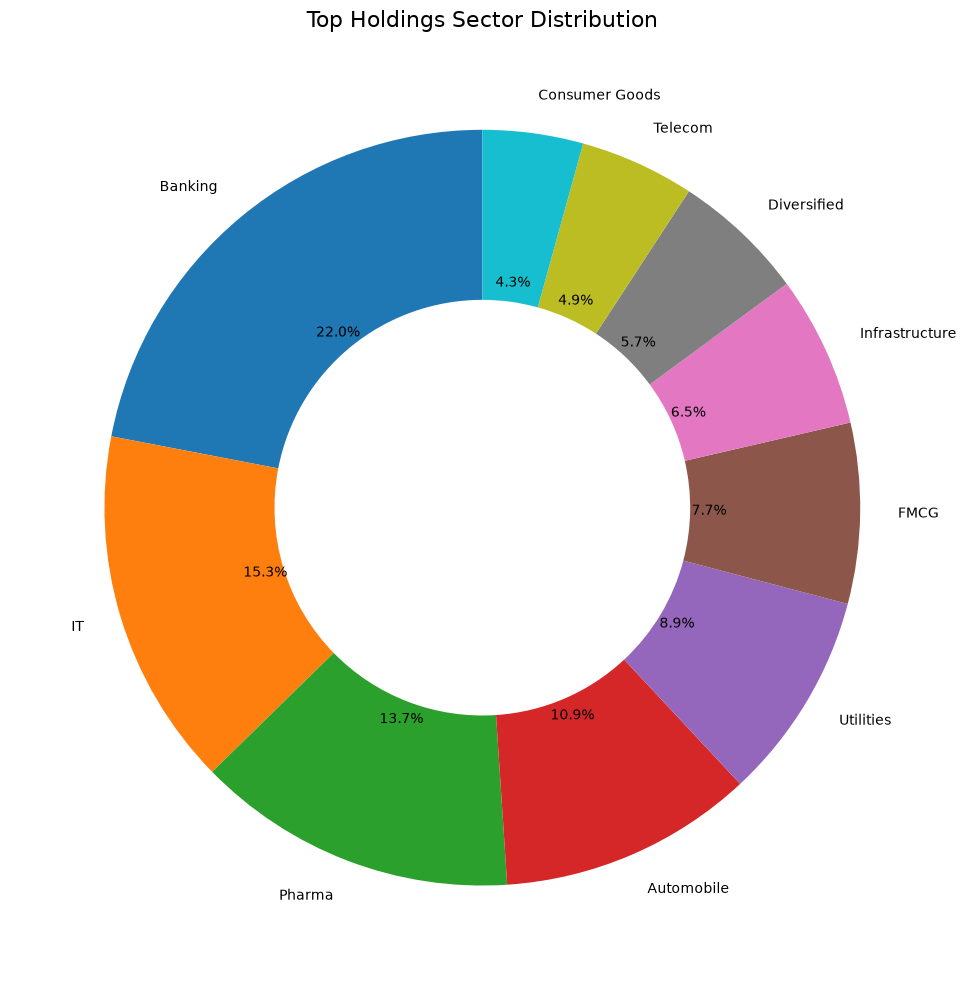


Task 9 completed successfully.
Chart saved to: Reports/Sector_Allocation.png


In [1]:

# DAY 3 - TASK 9: TOP HOLDINGS SECTOR DISTRIBUTION

import pandas as pd
import matplotlib.pyplot as plt

# Loading portfolio holdings data:
df = pd.read_csv("../Data/Raw/09_portfolio_holdings.csv")

# Cleaning column names:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())


# Identifying sector and weight columns:

sector_col = next(
    col for col in df.columns
    if "sector" in col
)

weight_col = next(
    col for col in df.columns
    if "weight" in col
)

# Converting weight to numeric:
df[weight_col] = pd.to_numeric(
    df[weight_col],
    errors="coerce"
)

# Removing missing values:
sector_df = df[
    [sector_col, weight_col]
].dropna()


# Calculating total sector allocation:

sector_allocation = (
    sector_df
    .groupby(sector_col)[weight_col]
    .sum()
    .sort_values(ascending=False)
)

print("\nSector Allocation:")
display(
    sector_allocation.to_frame(
        name="Total Weight"
    )
)


# Keeping top sectors:

top_sectors = sector_allocation.head(10)


# Creating donut chart:

plt.figure(figsize=(10, 10))

plt.pie(
    top_sectors.values,
    labels=top_sectors.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title(
    "Top Holdings Sector Distribution",
    fontsize=16
)

plt.tight_layout()

# Save chart:

plt.savefig(
    "../Reports/Sector_Allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nTask 9 completed successfully.")
print("Chart saved to: Reports/Sector_Allocation.png")